In [25]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay
from astroML.utils import completeness_contamination

In [34]:
data = pd.read_parquet('SGcolorSeparation.parquet')
features = ['ug', 'gr', 'ri', 'iz', 'zy']
data_clean = data.replace([np.inf, -np.inf], np.nan)
data_clean = data_clean.dropna(subset=features)

X = data_clean[features].values
y = data_clean['starFlag'].astype(int).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
print("Total NaNs:", np.isnan(X).sum())
print("Total Infs:", np.isinf(X).sum())
print("Max value:", np.nanmax(np.abs(X)))

Total NaNs: 0
Total Infs: 0
Max value: 59.169422


GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
LogisticRegression
KNeighborsClassifier
DecisionTreeClassifier
RandomForestClassifier
MLPClassifier


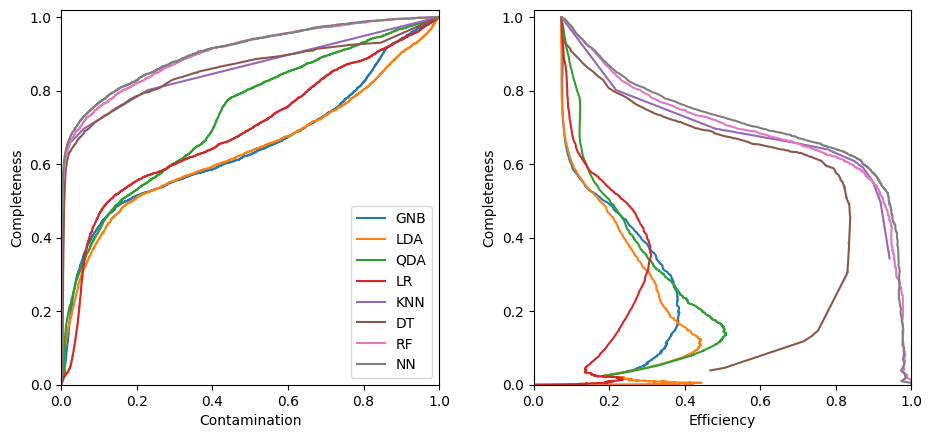

In [36]:
# This monkey-patch takes care of older astronomy packages that have not yet been updated for NumPy 2.x.
np.float = float


#------------------------------------------------------------
# Fit all the models to the training data
def compute_models(*args):
    names = []
    probs = []
    preds = []
    for classifier, kwargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        clf.fit(X_train, y_train)
        y_probs = clf.predict_proba(X_test)[:, 1]
        y_preds = clf.predict(X_test)

        names.append(classifier.__name__)
        probs.append(y_probs)
        preds.append(y_preds)

    return names, probs, preds


names, probs, preds = compute_models((GaussianNB, {}),
                                     (LinearDiscriminantAnalysis, {}),
                                     (QuadraticDiscriminantAnalysis, {}),
                                     (LogisticRegression, dict(class_weight='balanced')),
                                     (KNeighborsClassifier, dict(n_neighbors=10)),
                                     (DecisionTreeClassifier, dict(random_state=0, max_depth=12, criterion='entropy')),
                                     (RandomForestClassifier, dict(n_estimators=100, random_state=0, max_depth=12, criterion='entropy')),
                                     (MLPClassifier, dict(hidden_layer_sizes=(256, 128, 64), max_iter=1000, early_stopping=True, random_state=0))
)

#------------------------------------------------------------
# Plot ROC curves and completeness/efficiency
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)


# ax2 will show roc curves
ax1 = plt.subplot(121)

# ax1 will show completeness/efficiency
ax2 = plt.subplot(122)

labels = dict(GaussianNB='GNB',
              LinearDiscriminantAnalysis='LDA',
              QuadraticDiscriminantAnalysis='QDA',
              KNeighborsClassifier='KNN',
              DecisionTreeClassifier='DT',
              LogisticRegression='LR',
              RandomForestClassifier='RF',
              MLPClassifier='NN')

thresholds = np.linspace(0, 1, 1001)[:-1]

# iterate through and show results
for name, y_prob in zip(names, probs):
    fpr, tpr, thresh = roc_curve(y_test, y_prob)

    # add (0, 0) as first point
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])

    ax1.plot(fpr, tpr, label=labels[name])

    comp = np.zeros_like(thresholds)
    cont = np.zeros_like(thresholds)
    for i, t in enumerate(thresholds):
        y_pred = (y_prob >= t)
        comp[i], cont[i] = completeness_contamination(y_pred, y_test)
    ax2.plot(1 - cont, comp, label=labels[name])

ax1.set_xlim(0, 1.0)
ax1.set_ylim(0, 1.02)
ax1.set_xlabel('Contamination')
ax1.set_ylabel('Completeness')
ax1.legend(loc=4)

ax2.set_xlabel('Efficiency')
ax2.set_ylabel('Completeness')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(0, 1.02)

plt.show()

In [37]:
index = names.index('RandomForestClassifier')
y_pred_best = preds[index]

cm = confusion_matrix(y_test, y_pred_best)

tn, fp, fn, tp = cm.ravel()

total = np.sum(cm)
tp_pct = (tp / total) * 100
fp_pct = (fp / total) * 100
fn_pct = (fn / total) * 100
tn_pct = (tn / total) * 100

# [[TP, FP]
#  [FN, TN]]
print(f"[[{tp_pct:.2f}%, {fp_pct:.2f}%]")
print(f" [{fn_pct:.2f}%, {tn_pct:.2f}%]]")

[[4.30%, 0.63%]
 [3.11%, 91.96%]]


In [ ]:
index = names.index('MLPClassifier')
y_pred_best = preds[index]

cm = confusion_matrix(y_test, y_pred_best)

tn, fp, fn, tp = cm.ravel()

total = np.sum(cm)
tp_pct = (tp / total) * 100
fp_pct = (fp / total) * 100
fn_pct = (fn / total) * 100
tn_pct = (tn / total) * 100

# [[TP, FP]
#  [FN, TN]]
print(f"[[{tp_pct:.2f}%, {fp_pct:.2f}%]")
print(f" [{fn_pct:.2f}%, {tn_pct:.2f}%]]")

[[4.42%, 0.62%]
 [2.99%, 91.98%]]


: 